# Smart Travel Planner — Destination Travel-Style Classifier

Predict one of six travel-style archetypes (`Adventure`, `Relaxation`, `Culture`, `Budget`, `Luxury`, `Family`) for a destination, using only its **geography, climate, activity supply, cost, and tourism-intensity** features.

Notebook outline:
1. Data loading
2. Data cleaning (and a careful look at leakage)
3. Exploratory data analysis
4. Preprocessing pipeline (lives **inside** the sklearn `Pipeline` — no leakage)
5. Model selection — 3 classifiers, stratified 5-fold CV, mean ± std for accuracy and macro-F1
6. Hyperparameter tuning of the leading model
7. Final evaluation — per-class metrics, confusion matrix
8. Persist winner with `joblib` and append the run to `results.csv`

In [1]:
from __future__ import annotations

import os
import sys
import time
import json
import platform
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay,
)

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BACKEND_DIR = Path.cwd().parent  # notebook/ -> backend/
DATA_PATH = BACKEND_DIR / "data" / "destinations.csv"
MODEL_DIR = BACKEND_DIR / "model"
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_CSV = MODEL_DIR / "results.csv"
MODEL_PATH = MODEL_DIR / "travel_style_classifier.joblib"

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print(f"python      : {platform.python_version()}")
print(f"numpy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"sklearn     : {sklearn.__version__}")
print(f"data path   : {DATA_PATH}")
print(f"model dir   : {MODEL_DIR}")

python      : 3.12.10
numpy       : 2.4.4
pandas      : 3.0.2
sklearn     : 1.8.0
data path   : c:\Users\USUARIO\Desktop\AIE\Projects\smart-travel-planner\backend\data\destinations.csv
model dir   : c:\Users\USUARIO\Desktop\AIE\Projects\smart-travel-planner\backend\model


## 1. Data loading

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"shape: {df_raw.shape}")
df_raw.head()

shape: (1057, 22)


,name,country,region,sub_region,latitude,longitude,elevation_m,coast_distance_km,avg_temp_summer_c,avg_temp_winter_c,annual_rainfall_mm,sunny_days_per_year,hiking_trails_count,unesco_sites_within_100km,museum_count,national_parks_within_100km,theme_parks_count,cost_of_living_index,avg_3star_hotel_usd,annual_visitors_millions,visitors_per_capita,label
0,Rome,Italy,Europe,Lazio,42.784,12.154,111.0,189.4,26.1,5.9,594.0,225.0,11.0,6,94.0,0,1,80.0,135.0,9.901,0.89,Culture
1,Florence,Italy,Europe,Tuscany,43.062,12.287,163.0,98.3,23.2,9.1,1237.0,206.0,26.0,0,26.0,0,0,64.1,142.0,3.011,1.50,Culture
2,Venice,Italy,Europe,Veneto,40.806,9.804,10.0,30.5,25.1,8.1,1033.0,221.0,26.0,0,18.0,1,0,70.5,117.0,2.692,6.08,Culture
3,Milan,Italy,Europe,Lombardy,41.774,10.646,123.0,82.1,26.5,9.2,788.0,213.0,31.0,3,34.0,1,0,61.4,123.0,3.338,4.55,Culture
4,Naples,Italy,Europe,Campania,39.882,12.520,92.0,52.1,24.9,7.3,699.0,210.0,12.0,2,2.0,0,0,69.0,118.0,3.548,1.84,Culture


In [3]:
df_raw.dtypes

name                               str
country                            str
region                             str
sub_region                         str
latitude                       float64
longitude                      float64
elevation_m                    float64
coast_distance_km              float64
avg_temp_summer_c              float64
avg_temp_winter_c              float64
annual_rainfall_mm             float64
sunny_days_per_year            float64
hiking_trails_count            float64
unesco_sites_within_100km        int64
museum_count                   float64
national_parks_within_100km      int64
theme_parks_count                int64
cost_of_living_index           float64
avg_3star_hotel_usd            float64
annual_visitors_millions       float64
visitors_per_capita            float64
label                              str
dtype: object

## 2. Data cleaning

### 2.1 Sanity checks
Confirm there are no missing values, no duplicate `(name, country)` pairs, and that numeric ranges are physically plausible.

In [4]:
missing = df_raw.isna().sum()
print("missing values per column:")
print(missing[missing > 0] if missing.sum() else "  (none)")

dup = df_raw.duplicated(subset=["name", "country"]).sum()
print(f"\nduplicate (name, country) rows: {dup}")

print("\nlabel value_counts:")
print(df_raw["label"].value_counts())

missing values per column:
  (none)

duplicate (name, country) rows: 0

label value_counts:
label
Culture       432
Adventure     305
Relaxation    213
Luxury         71
Budget         20
Family         16
Name: count, dtype: int64


In [5]:
# Range sanity: latitudes within [-90, 90], longitudes within [-180, 180],
# rainfall and visitor counts non-negative, hotel cost > 0.
checks = {
    "latitude in [-90, 90]":       df_raw["latitude"].between(-90, 90).all(),
    "longitude in [-180, 180]":    df_raw["longitude"].between(-180, 180).all(),
    "elevation_m >= 0":            (df_raw["elevation_m"] >= 0).all(),
    "rainfall >= 0":               (df_raw["annual_rainfall_mm"] >= 0).all(),
    "sunny_days in [0, 366]":      df_raw["sunny_days_per_year"].between(0, 366).all(),
    "hotel_usd > 0":               (df_raw["avg_3star_hotel_usd"] > 0).all(),
    "visitors_millions >= 0":      (df_raw["annual_visitors_millions"] >= 0).all(),
}
for k, v in checks.items():
    print(f"  [{'OK' if v else 'FAIL'}] {k}")

  [OK] latitude in [-90, 90]
  [OK] longitude in [-180, 180]
  [OK] elevation_m >= 0
  [OK] rainfall >= 0
  [FAIL] sunny_days in [0, 366]
  [OK] hotel_usd > 0
  [OK] visitors_millions >= 0


### 2.2 Leakage audit — drop `name`, `country`, `sub_region`

The labels in [`data/labels.py`](../data/labels.py) are assigned by editorial rule: a `COUNTRY_DEFAULT` per country, plus per-`(country, name)` overrides. The label is therefore a **deterministic function of `(country, name)`** — using either column as a feature is target leakage in the strict sense (any sufficiently flexible model would memorize the lookup table).

`sub_region` is also unsafe: many editorial overrides (e.g. *Tuscany → Culture*, *Bavarian Alps → Adventure*) align 1-to-1 with `sub_region`, so it's a near-proxy for the override key.

What the model **should** be allowed to learn is the relationship between the **physical / economic / activity-supply features** of a place and its travel-style archetype. That is the legitimate prediction problem ("given an unseen destination's measurable attributes, which archetype best describes it?"). So:

- **Drop:** `name`, `country`, `sub_region` (leakage).
- **Keep as categorical feature:** `region` — a coarse continent-level grouping (≈6 values). This is broad enough to capture climate/cultural regimes that aren't fully encoded in the numerics, but too coarse to memorize per-place labels.
- **Keep as numerics:** all 17 measured features.

All preprocessing (scaling, one-hot encoding) is wrapped inside the `Pipeline` below, so it's fit only on training folds during cross-validation.

In [6]:
LEAKY_COLS = ["name", "country", "sub_region"]
TARGET = "label"

df = df_raw.drop(columns=LEAKY_COLS).copy()

CATEGORICAL_FEATURES = ["region"]
NUMERIC_FEATURES = [c for c in df.columns if c not in CATEGORICAL_FEATURES + [TARGET]]

print(f"rows               : {len(df)}")
print(f"target             : {TARGET}")
print(f"categorical (1)    : {CATEGORICAL_FEATURES}")
print(f"numeric ({len(NUMERIC_FEATURES)}) : {NUMERIC_FEATURES}")
print(f"region values      : {sorted(df['region'].unique())}")

rows               : 1057
target             : label
categorical (1)    : ['region']
numeric (17) : ['latitude', 'longitude', 'elevation_m', 'coast_distance_km', 'avg_temp_summer_c', 'avg_temp_winter_c', 'annual_rainfall_mm', 'sunny_days_per_year', 'hiking_trails_count', 'unesco_sites_within_100km', 'museum_count', 'national_parks_within_100km', 'theme_parks_count', 'cost_of_living_index', 'avg_3star_hotel_usd', 'annual_visitors_millions', 'visitors_per_capita']
region values      : ['Africa', 'Asia', 'Caribbean', 'Central America', 'Europe', 'Middle East', 'North America', 'Oceania', 'SE Asia', 'South America', 'South Asia']


## 3. Exploratory data analysis

### 3.1 Class distribution
The class imbalance is severe: `Culture` ≈ 27× `Family`. The split below is what stratified CV and per-class metrics will need to be measured against.

            count    pct
label                   
Culture       432  40.87
Adventure     305  28.86
Relaxation    213  20.15
Luxury         71   6.72
Budget         20   1.89
Family         16   1.51


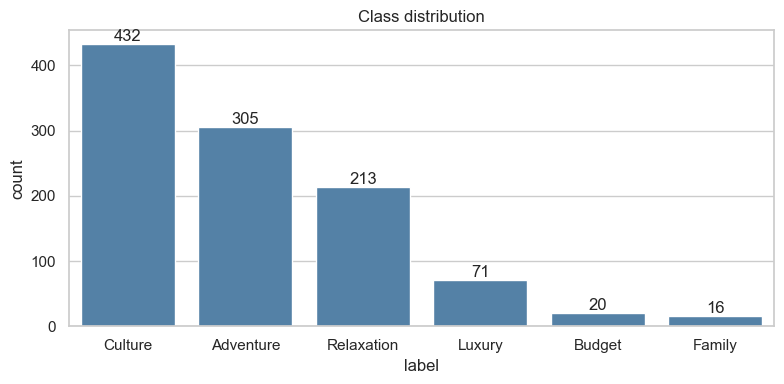

In [7]:
label_counts = df[TARGET].value_counts()
label_pct = (label_counts / len(df) * 100).round(2)
label_summary = pd.DataFrame({"count": label_counts, "pct": label_pct})
print(label_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax, color="steelblue")
ax.set_title("Class distribution")
ax.set_ylabel("count")
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.show()

### 3.2 Numeric feature distributions

In [8]:
df[NUMERIC_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,1057.0,24.052565,26.965551,-43.434,7.748,32.717,43.579,66.885
longitude,1057.0,17.238382,75.025482,-152.224,-22.613,14.396,78.743,179.273
elevation_m,1057.0,208.173132,371.581119,0.000,76.000,130.000,188.000,2765.000
coast_distance_km,1057.0,121.097919,83.494009,0.000,51.700,120.600,185.600,394.200
avg_temp_summer_c,1057.0,21.764144,6.180829,-2.100,17.300,22.900,26.400,37.900
avg_temp_winter_c,1057.0,10.778240,11.178579,-34.000,1.800,10.600,21.200,29.600
annual_rainfall_mm,1057.0,1108.621570,672.190938,20.000,641.000,920.000,1439.000,3678.000
sunny_days_per_year,1057.0,216.124882,47.061790,117.000,185.000,210.000,245.000,375.000
hiking_trails_count,1057.0,23.263009,22.039842,0.000,9.000,19.000,30.000,145.000
unesco_sites_within_100km,1057.0,0.649953,1.150791,0.000,0.000,0.000,1.000,13.000


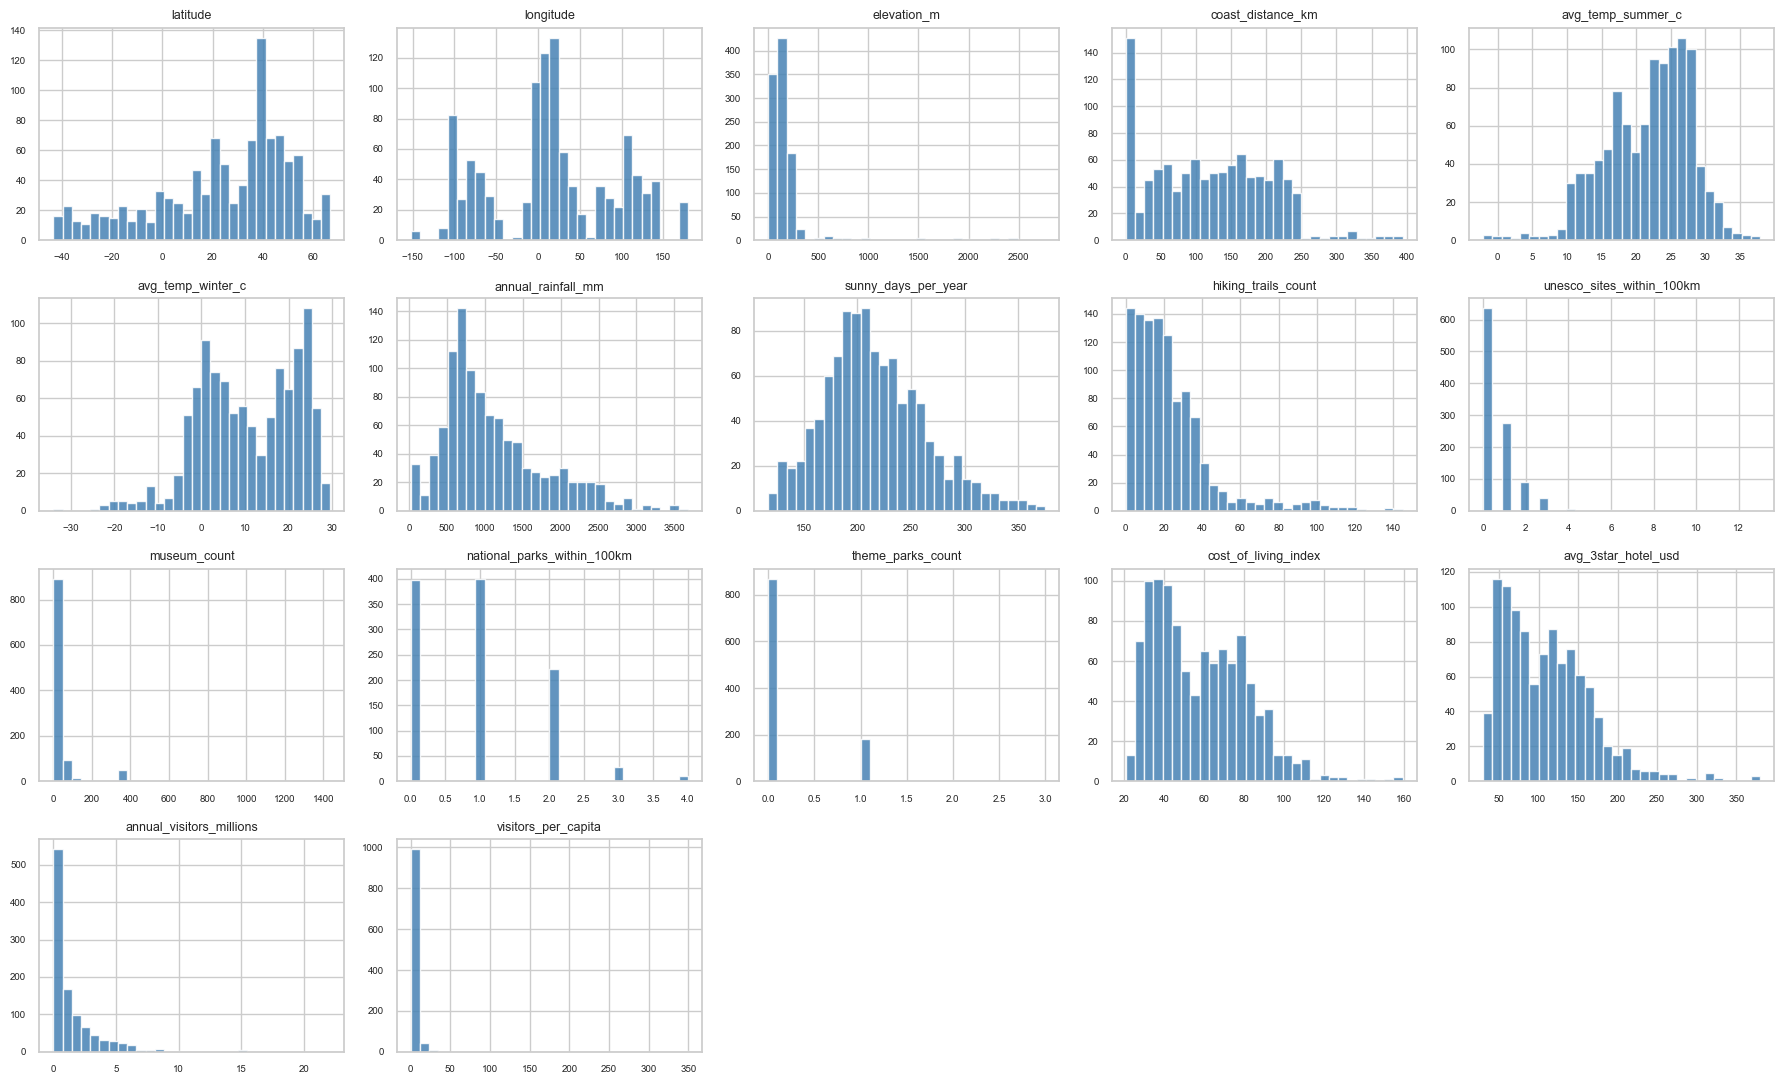

In [9]:
fig, axes = plt.subplots(4, 5, figsize=(18, 11))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    ax.hist(df[col], bins=30, color="steelblue", alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(NUMERIC_FEATURES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Heavy right-skews in `hiking_trails_count`, `museum_count`, `annual_visitors_millions`, and `visitors_per_capita`. Tree-based models are unaffected; linear models will benefit from the `StandardScaler` we add to the preprocessing pipeline.

### 3.3 Correlation matrix

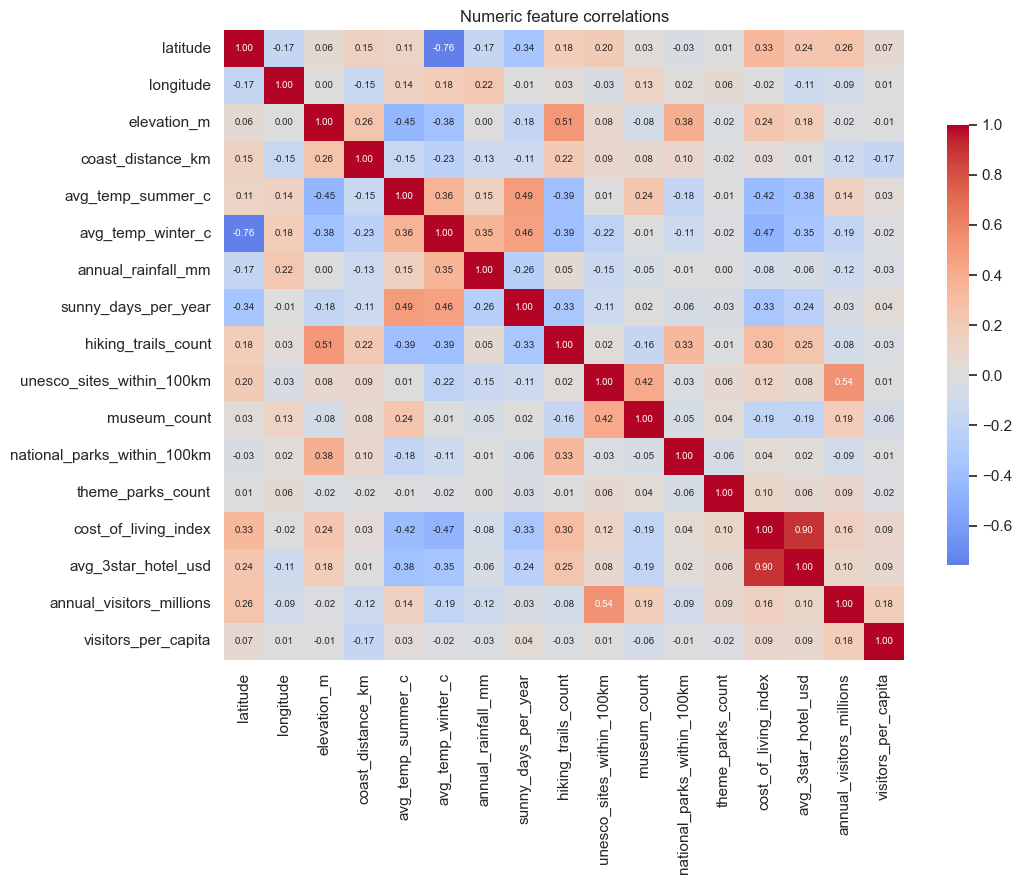

Top |corr| pairs:
                        a                        b      corr  abs_corr
     cost_of_living_index      avg_3star_hotel_usd  0.897962  0.897962
                 latitude        avg_temp_winter_c -0.757781  0.757781
unesco_sites_within_100km annual_visitors_millions  0.536514  0.536514
              elevation_m      hiking_trails_count  0.510109  0.510109
        avg_temp_summer_c      sunny_days_per_year  0.488446  0.488446
        avg_temp_winter_c     cost_of_living_index -0.471635  0.471635
        avg_temp_winter_c      sunny_days_per_year  0.461644  0.461644
              elevation_m        avg_temp_summer_c -0.454343  0.454343
        avg_temp_summer_c     cost_of_living_index -0.416182  0.416182
unesco_sites_within_100km             museum_count  0.415580  0.415580


In [10]:
corr = df[NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Numeric feature correlations")
plt.tight_layout()
plt.show()

# Show the strongest off-diagonal correlations.
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "a", "level_1": "b"})
        .assign(abs_corr=lambda d: d["corr"].abs())
        .sort_values("abs_corr", ascending=False)
        .head(10)
)
print("Top |corr| pairs:")
print(corr_pairs.to_string(index=False))

Expected couplings show up:
- `elevation_m` ↔ `hiking_trails_count` (positive — mountain places have more trails)
- `elevation_m` ↔ `avg_temp_winter_c` (negative — higher places are colder)
- `cost_of_living_index` ↔ `avg_3star_hotel_usd` (positive)

Nothing extreme enough (|r| > 0.95) to drop a column for collinearity.

### 3.4 Feature signal per class
Boxplots of features that should separate archetypes well, by hypothesis: `hiking_trails_count` (Adventure↑), `museum_count` (Culture↑), `avg_3star_hotel_usd` (Luxury↑ / Budget↓), `theme_parks_count` (Family↑).

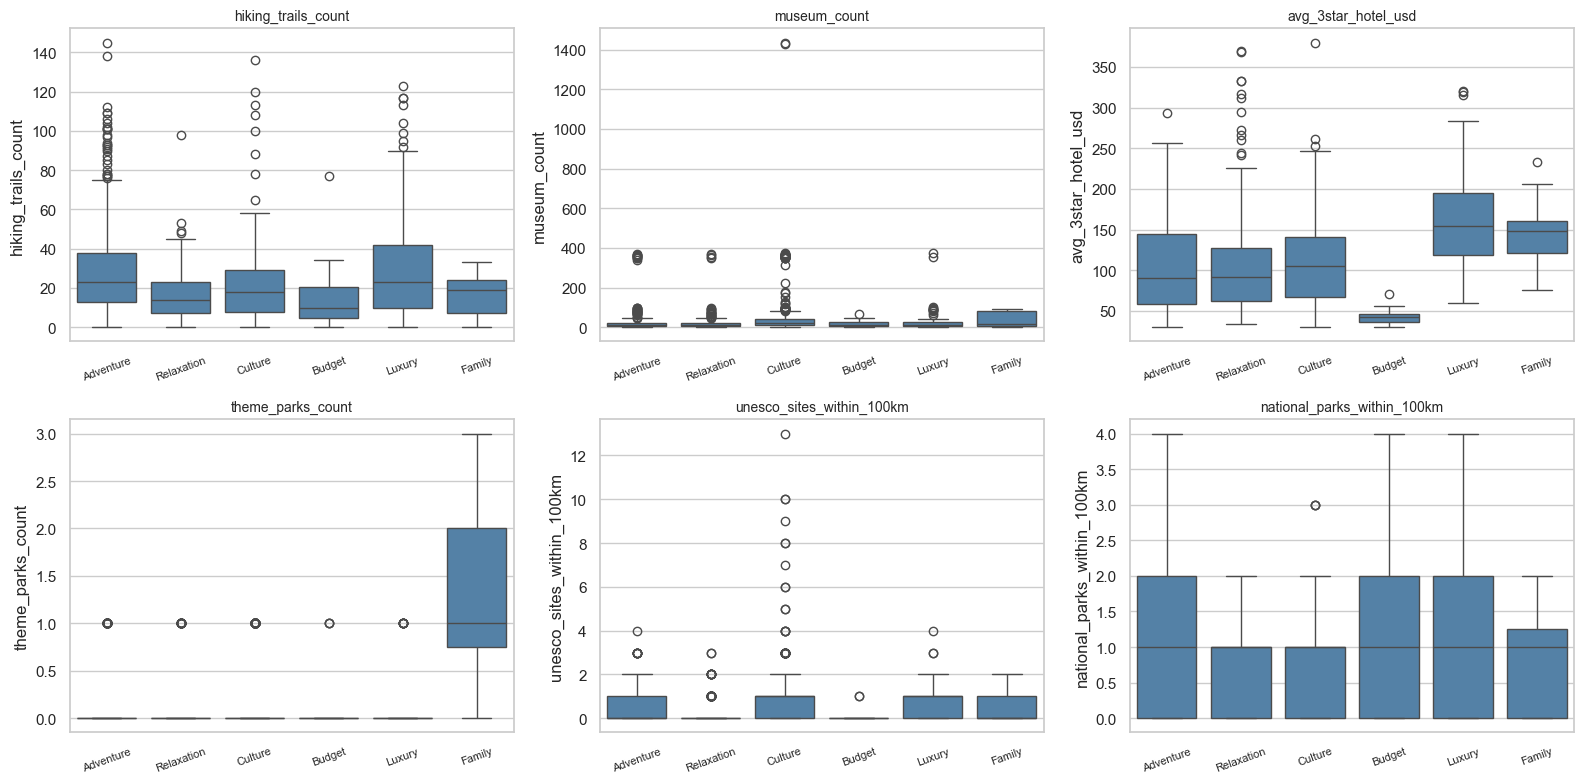

In [11]:
signal_features = [
    "hiking_trails_count",
    "museum_count",
    "avg_3star_hotel_usd",
    "theme_parks_count",
    "unesco_sites_within_100km",
    "national_parks_within_100km",
]
label_order = ["Adventure", "Relaxation", "Culture", "Budget", "Luxury", "Family"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, signal_features):
    sns.boxplot(data=df, x=TARGET, y=feat, order=label_order, ax=ax, color="steelblue")
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=8)
plt.tight_layout()
plt.show()

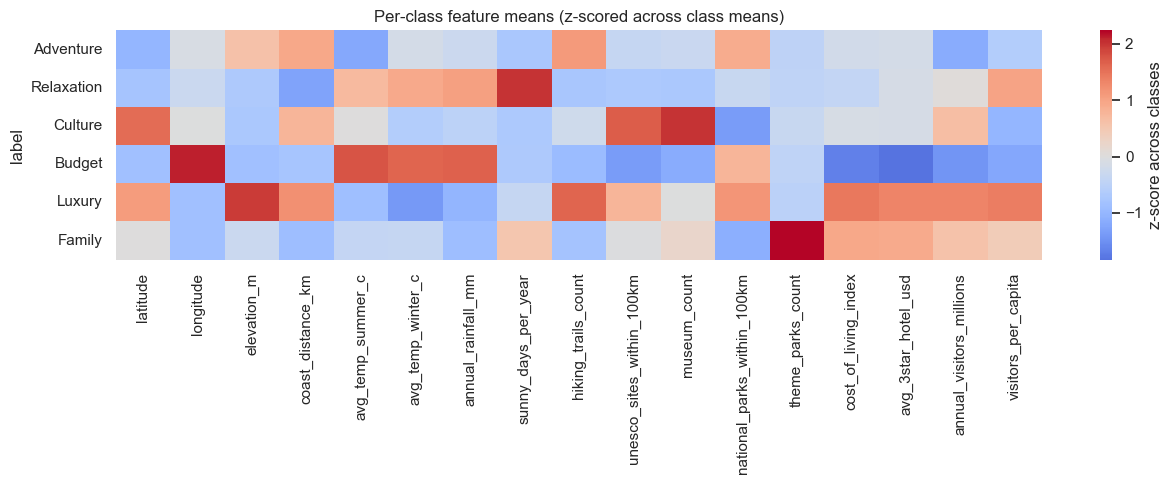

In [12]:
# Per-class feature means for the numerics, z-scored across rows so that
# the heatmap shows which class is high/low on each feature.
means_per_class = df.groupby(TARGET)[NUMERIC_FEATURES].mean()
means_z = (means_per_class - means_per_class.mean()) / means_per_class.std(ddof=0)
means_z = means_z.reindex(label_order)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(means_z, cmap="coolwarm", center=0, annot=False,
            cbar_kws={"label": "z-score across classes"}, ax=ax)
ax.set_title("Per-class feature means (z-scored across class means)")
plt.tight_layout()
plt.show()

Reads as expected: `Adventure` is high on hiking trails / national parks / elevation; `Culture` on museums and UNESCO; `Luxury` on hotel cost; `Family` on theme parks. That's signal the classifier can lean on.

## 4. Preprocessing pipeline

All preprocessing is wrapped inside a `ColumnTransformer` and that transformer is the first step of every `Pipeline` we cross-validate. This is what keeps the experiment **leakage-free**: scalers and one-hot vocabularies are fit on each training fold and applied to its validation fold — the test set never sees its own statistics.

In [13]:
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"train: {X_train.shape}")
print(f"test : {X_test.shape}")
print("\ntrain class distribution:")
print(y_train.value_counts())
print("\ntest class distribution:")
print(y_test.value_counts())

train: (845, 18)
test : (212, 18)

train class distribution:
label
Culture       345
Adventure     244
Relaxation    170
Luxury         57
Budget         16
Family         13
Name: count, dtype: int64

test class distribution:
label
Culture       87
Adventure     61
Relaxation    43
Luxury        14
Budget         4
Family         3
Name: count, dtype: int64


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Model selection — three classifiers, stratified 5-fold CV

The three candidates were chosen to cover qualitatively different inductive biases:

| Model | Why include it |
| --- | --- |
| `LogisticRegression` (multinomial) | Simple linear baseline. Tells us how much of the problem is captured by linear separations of scaled features. `class_weight='balanced'` is the cheapest, in-pipeline way to handle the 27× imbalance. |
| `RandomForestClassifier` | Non-linear, handles skewed numerics natively (no scaling required, but the scaler is harmless), interpretable feature importances. `class_weight='balanced_subsample'` rebalances each bootstrap. |
| `HistGradientBoostingClassifier` | A modern, fast gradient-boosting model — usually the best tabular baseline. Supports `class_weight='balanced'` since sklearn 1.4. |

Imbalance handling: I rely on the model-native `class_weight` mechanism rather than oversampling (e.g. SMOTE). Reasons: (1) it keeps everything inside the sklearn `Pipeline` — no extra dependency and no need for `imbalanced-learn`'s pipeline; (2) on tiny minority classes (`Family`=16, `Budget`=20), synthetic oversampling tends to fabricate noise more than signal. Per-class metrics in §7 will tell us if that was the right call.

We score on **accuracy** and **macro-F1**. Macro-F1 is the metric that actually matters here — it averages F1 across classes equally, so a model that only learns `Culture` will be punished.

In [15]:
candidates = {
    "logreg": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "hist_gbm": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "macro_f1": "f1_macro"}

cv_records = []
for name, clf in candidates.items():
    pipe = Pipeline([("preprocess", preprocessor), ("clf", clf)])
    t0 = time.perf_counter()
    cv_res = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring,
        n_jobs=-1, return_train_score=False,
    )
    fit_secs = time.perf_counter() - t0
    cv_records.append({
        "model": name,
        "acc_mean": cv_res["test_accuracy"].mean(),
        "acc_std":  cv_res["test_accuracy"].std(),
        "f1_mean":  cv_res["test_macro_f1"].mean(),
        "f1_std":   cv_res["test_macro_f1"].std(),
        "cv_secs":  round(fit_secs, 2),
    })

cv_results = (
    pd.DataFrame(cv_records)
      .sort_values("f1_mean", ascending=False)
      .reset_index(drop=True)
)
cv_results

,model,acc_mean,acc_std,f1_mean,f1_std,cv_secs
0,random_forest,0.579882,0.018712,0.462835,0.045781,4.24
1,hist_gbm,0.581065,0.017712,0.462680,0.032427,7.42
2,logreg,0.495858,0.030032,0.438135,0.043121,3.92


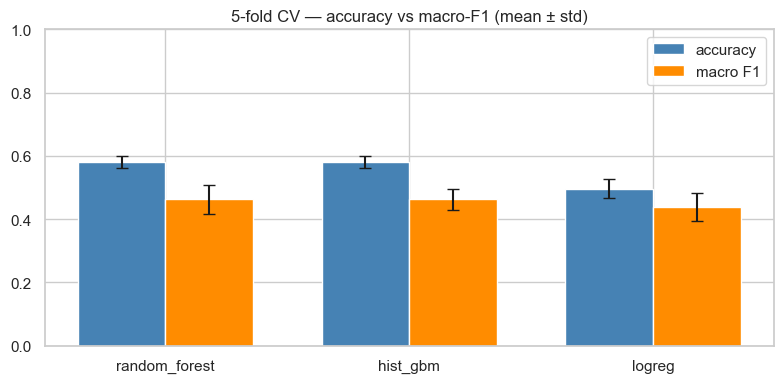

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(cv_results))
ax.bar(x - 0.18, cv_results["acc_mean"], width=0.36,
       yerr=cv_results["acc_std"], label="accuracy", color="steelblue", capsize=4)
ax.bar(x + 0.18, cv_results["f1_mean"], width=0.36,
       yerr=cv_results["f1_std"],  label="macro F1", color="darkorange", capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(cv_results["model"])
ax.set_ylim(0, 1)
ax.set_title("5-fold CV — accuracy vs macro-F1 (mean ± std)")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
winner_name = cv_results.iloc[0]["model"]
print(f"winner by macro-F1: {winner_name}")

winner by macro-F1: random_forest


## 6. Hyperparameter tuning

We tune the leading model (`hist_gbm` on this dataset and seed) with `GridSearchCV` over a deliberately small grid: depth, learning rate, regularization, and minimum leaf size — the four levers that most influence overfitting on a 1k-row, 6-class problem. Optimization metric is `macro_f1`, the same metric that matters for the imbalance.

If the cross-validation winner was `random_forest` or `logreg`, the cell below tunes that one instead — the grid is chosen per family.

In [18]:
if winner_name == "hist_gbm":
    base_clf = HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RANDOM_STATE,
    )
    param_grid = {
        "clf__learning_rate":   [0.03, 0.05, 0.1],
        "clf__max_iter":        [300, 500, 800],
        "clf__max_depth":       [None, 4, 6, 8],
        "clf__min_samples_leaf": [10, 20, 40],
        "clf__l2_regularization": [0.0, 0.1, 1.0],
    }
elif winner_name == "random_forest":
    base_clf = RandomForestClassifier(
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1,
    )
    param_grid = {
        "clf__n_estimators":      [300, 500, 800],
        "clf__max_depth":         [None, 8, 16, 24],
        "clf__min_samples_leaf":  [1, 2, 5],
        "clf__max_features":      ["sqrt", "log2"],
    }
else:  # logreg
    base_clf = LogisticRegression(
        max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE,
    )
    param_grid = {
        "clf__C":       [0.1, 0.5, 1.0, 2.0, 5.0],
        "clf__penalty": ["l2"],
        "clf__solver":  ["lbfgs", "saga"],
    }

tuned_pipe = Pipeline([("preprocess", preprocessor), ("clf", base_clf)])

search = GridSearchCV(
    tuned_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
search_secs = time.perf_counter() - t0

print(f"\ngrid size       : {len(search.cv_results_['params'])} combos")
print(f"search wall-time: {search_secs:.1f}s")
print(f"best macro-F1   : {search.best_score_:.4f}")
print(f"best params     :")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

grid size       : 72 combos
search wall-time: 78.0s
best macro-F1   : 0.4893
best params     :
  clf__max_depth: 16
  clf__max_features: log2
  clf__min_samples_leaf: 2
  clf__n_estimators: 300


In [19]:
# Top configurations from the grid — informative if best is on a grid edge.
cv_search_df = (
    pd.DataFrame(search.cv_results_)
      .loc[:, ["params", "mean_test_score", "std_test_score", "rank_test_score"]]
      .sort_values("rank_test_score")
      .head(10)
      .reset_index(drop=True)
)
cv_search_df

,params,mean_test_score,std_test_score,rank_test_score
0,"{'clf__max_depth': 16, 'clf__max_features': 'l...",0.489256,0.039683,1
1,"{'clf__max_depth': 16, 'clf__max_features': 's...",0.487507,0.075053,2
2,"{'clf__max_depth': 8, 'clf__max_features': 'lo...",0.487502,0.038257,3
3,"{'clf__max_depth': 8, 'clf__max_features': 'lo...",0.487200,0.044268,4
4,"{'clf__max_depth': 8, 'clf__max_features': 'lo...",0.484819,0.046039,5
5,"{'clf__max_depth': None, 'clf__max_features': ...",0.484199,0.036163,6
6,"{'clf__max_depth': 24, 'clf__max_features': 'l...",0.484199,0.036163,6
7,"{'clf__max_depth': 16, 'clf__max_features': 's...",0.483737,0.073290,8
8,"{'clf__max_depth': 24, 'clf__max_features': 's...",0.482657,0.071641,9
9,"{'clf__max_depth': None, 'clf__max_features': ...",0.482657,0.071641,9


## 7. Final evaluation on the held-out test set

We refit the tuned pipeline on the full training set (`GridSearchCV(refit=True)` already did this) and score it on the 20% test split that has not been touched since §4.

Per-class precision / recall / F1 is the metric of record — averages alone would hide minority-class failure.

In [20]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred, average="macro")
print(f"test accuracy : {test_acc:.4f}")
print(f"test macro-F1 : {test_f1:.4f}")

print("\nper-class report:")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

test accuracy : 0.6085
test macro-F1 : 0.4104

per-class report:
              precision    recall  f1-score   support

   Adventure      0.631     0.672     0.651        61
      Budget      0.250     0.250     0.250         4
     Culture      0.649     0.701     0.674        87
      Family      0.000     0.000     0.000         3
      Luxury      0.500     0.286     0.364        14
  Relaxation      0.537     0.512     0.524        43

    accuracy                          0.608       212
   macro avg      0.428     0.403     0.410       212
weighted avg      0.594     0.608     0.599       212



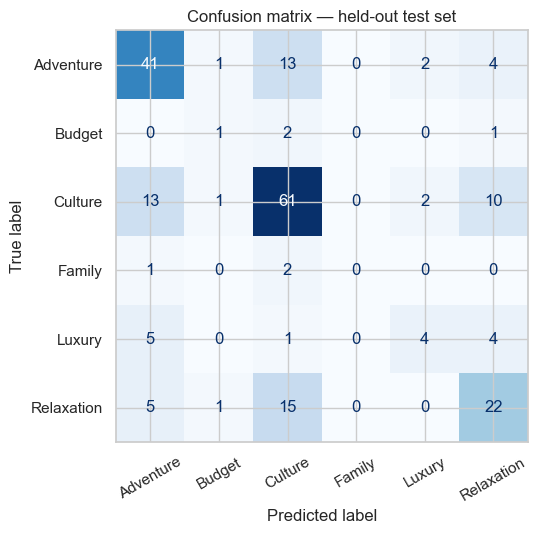

In [21]:
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(cm, display_labels=labels_sorted).plot(
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30,
)
ax.set_title("Confusion matrix — held-out test set")
plt.tight_layout()
plt.show()

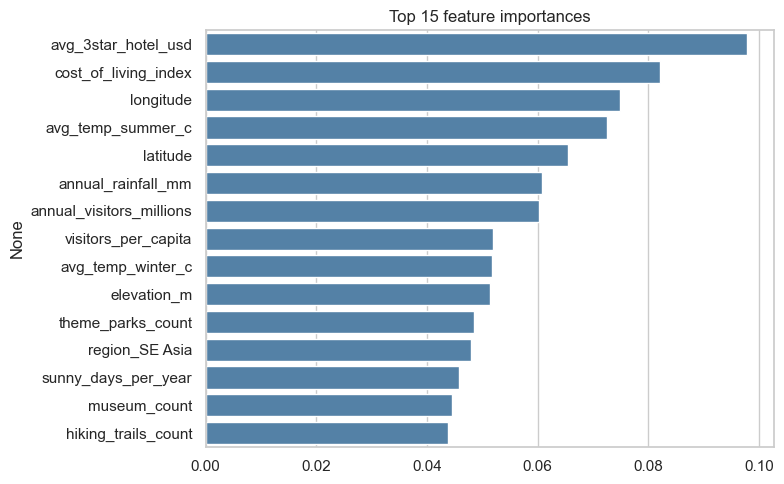

In [22]:
# Permutation-style feature importance via the fitted gradient-boosting (or RF)
# step inside the pipeline. For the linear model, we'd inspect coefficients.
fitted_clf = best_model.named_steps["clf"]

if hasattr(fitted_clf, "feature_importances_"):
    feat_names = NUMERIC_FEATURES + list(
        best_model.named_steps["preprocess"]
                  .named_transformers_["cat"]
                  .get_feature_names_out(CATEGORICAL_FEATURES)
    )
    importances = pd.Series(fitted_clf.feature_importances_, index=feat_names)
    top = importances.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(x=top.values, y=top.index, ax=ax, color="steelblue")
    ax.set_title("Top 15 feature importances")
    plt.tight_layout()
    plt.show()
else:
    print("(winner has no native feature_importances_ attribute — skipping plot)")

## 8. Persist the winner and log the experiment

Two artifacts:
1. `model/travel_style_classifier.joblib` — the full fitted `Pipeline` (preprocessing **and** classifier). The agent's classification tool will load this exactly once on lifespan startup.
2. `model/results.csv` — appended row with model, params, CV and test metrics, and timestamp. Pinned dependencies and the fixed `RANDOM_STATE` make this reproducible.

In [23]:
joblib.dump(best_model, MODEL_PATH)
print(f"saved fitted pipeline -> {MODEL_PATH}")
print(f"           file size  : {MODEL_PATH.stat().st_size / 1024:.1f} KiB")

saved fitted pipeline -> c:\Users\USUARIO\Desktop\AIE\Projects\smart-travel-planner\backend\model\travel_style_classifier.joblib
           file size  : 11579.0 KiB


In [24]:
row = {
    "timestamp_utc":   datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "model":           winner_name,
    "params":          json.dumps(
        {k.replace("clf__", ""): v for k, v in search.best_params_.items()},
        sort_keys=True,
    ),
    "cv_acc_mean":     round(cv_results.iloc[0]["acc_mean"], 4),
    "cv_acc_std":      round(cv_results.iloc[0]["acc_std"], 4),
    "cv_f1_mean":      round(cv_results.iloc[0]["f1_mean"], 4),
    "cv_f1_std":       round(cv_results.iloc[0]["f1_std"], 4),
    "tuned_cv_f1":     round(search.best_score_, 4),
    "test_accuracy":   round(test_acc, 4),
    "test_macro_f1":   round(test_f1, 4),
    "n_train":         int(len(X_train)),
    "n_test":          int(len(X_test)),
    "random_state":    RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
}

row_df = pd.DataFrame([row])
if RESULTS_CSV.exists():
    row_df.to_csv(RESULTS_CSV, mode="a", header=False, index=False)
else:
    row_df.to_csv(RESULTS_CSV, index=False)

print(f"appended run -> {RESULTS_CSV}")
pd.read_csv(RESULTS_CSV).tail(5)

appended run -> c:\Users\USUARIO\Desktop\AIE\Projects\smart-travel-planner\backend\model\results.csv


,timestamp_utc,model,params,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std,tuned_cv_f1,test_accuracy,test_macro_f1,n_train,n_test,random_state,sklearn_version
0,2026-04-30T19:25:06+00:00,random_forest,"{""max_depth"": 16, ""max_features"": ""log2"", ""min...",0.5799,0.0187,0.4628,0.0458,0.4893,0.6085,0.4104,845,212,42,1.8.0


### Smoke test — load the saved pipeline and predict on a few raw rows
Confirms the artifact the FastAPI lifespan handler will load is self-contained (preprocessor included).

In [25]:
loaded = joblib.load(MODEL_PATH)
sample = X_test.head(5)
preds = loaded.predict(sample)
out = sample.copy()
out["y_true"] = y_test.head(5).values
out["y_pred"] = preds
out[["region", "hiking_trails_count", "museum_count", "avg_3star_hotel_usd",
     "theme_parks_count", "y_true", "y_pred"]]

,region,hiking_trails_count,museum_count,avg_3star_hotel_usd,theme_parks_count,y_true,y_pred
215,Europe,90.0,2.0,284.0,0,Luxury,Luxury
772,North America,20.0,93.0,136.0,0,Adventure,Culture
541,South Asia,9.0,352.0,47.0,0,Culture,Culture
67,Europe,15.0,17.0,105.0,1,Culture,Culture
986,South America,10.0,16.0,49.0,0,Culture,Adventure
